# Machine Learning Lifecycle Tutorial

This notebook demonstrates the **full ML model lifecycle** in the QuantStrata library: from configuration and data building through training, evaluation, inference, and hyperparameter tuning. Each step uses the same **generic pipelines**; only the **data builder** and **model** are model-specific (here we use the pricing model).

You will see:
- **Configuration** as separate training and model dictionaries (easy to load from YAML).
- **Data pipeline** producing `tf.data.Dataset`(s).
- **Model instance** built from config.
- **Training**, **evaluation**, **inference**, and **tuning** pipelines with standardised outputs and visualisations.

---
## 0. Overview & pipeline map

The lifecycle has six main pipelines. Each consumes standardised inputs and produces standardised outputs so you can swap models or data builders without changing the rest of the flow.

| Pipeline | Module | Inputs | Output | Standardised type |
|----------|--------|--------|--------|--------------------|
| **Data** | `data.pricing` | config (n_samples, splits, …) | train_ds, val_ds, test_ds | `PricingDataResult` |
| **Model** | `models.pricing` | model config dict | Keras model | `MLPPricer` |
| **Training** | Keras / `training` | model, train_ds, val_ds | history | — |
| **Evaluation** | `pipeline.evaluation` | model adapter, features, targets | metrics, summary | `EvaluationResult` |
| **Inference** | `inference` | model, path, stats | artifact, predictions | `ModelArtifact` |
| **Tuning** | `pipeline.tuning` | objective_fn, search_space | best_config, trials | `TuningResult` |

**Where things live:** `src/m_learning/` contains `core/`, `data/`, `pipeline/`, `training/`, `evaluation/`, `inference/`, and `models/`. Data and model are per-model (e.g. `data.pricing`, `models.pricing`); the rest are generic.

/var/folders/x6/k5s5xs4135d241wcn54pxjdh0000gn/T/ipykernel_12029/3098637580.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = mpatches.FancyBboxPatch((x - 0.45, y - 0.35), 0.9, 0.7, boxstyle="round,pad=0.02",


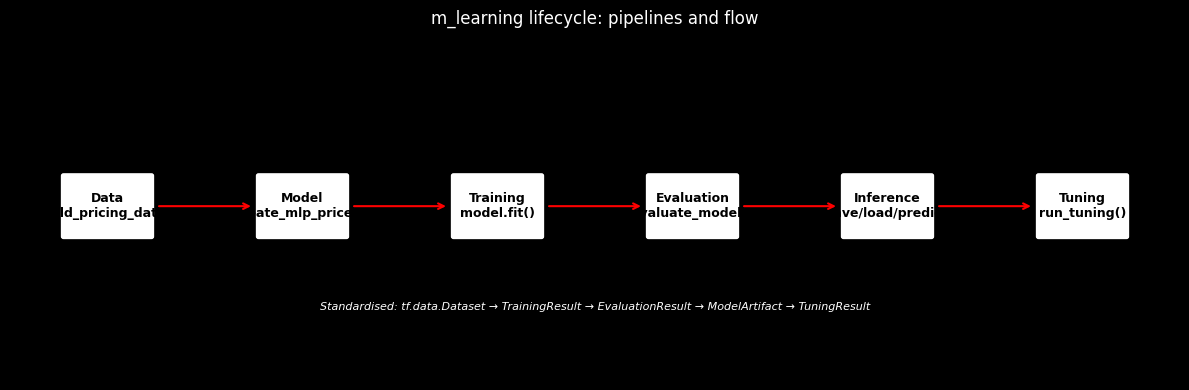

In [6]:
# Pipeline flow diagram: Data → Model → Training → Evaluation → Inference; Tuning runs Training+Eval repeatedly
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.axis("off")

boxes = [
    (1, 2, "Data\nbuild_pricing_data()", "#e3f2fd"),
    (3, 2, "Model\ncreate_mlp_pricer()", "#e8f5e9"),
    (5, 2, "Training\nmodel.fit()", "#fff3e0"),
    (7, 2, "Evaluation\nevaluate_model()", "#fce4ec"),
    (9, 2, "Inference\nsave/load/predict", "#f3e5f5"),
    (11, 2, "Tuning\nrun_tuning()", "#e0f2f1"),
]
for x, y, label, color in boxes:
    rect = mpatches.FancyBboxPatch((x - 0.45, y - 0.35), 0.9, 0.7, boxstyle="round,pad=0.02", 
                                    facecolor=color, edgecolor="white", linewidth=1.2, color="white")
    ax.add_patch(rect)
    ax.text(x, y, label, ha="center", va="center", fontsize=9, fontweight="bold", color="black")

for i in range(len(boxes) - 1):
    ax.annotate("", xy=(boxes[i + 1][0] - 0.5, 2), xytext=(boxes[i][0] + 0.5, 2),
                arrowprops=dict(arrowstyle="->", color="red", lw=1.5))
ax.text(6, 0.8, "Standardised: tf.data.Dataset → TrainingResult → EvaluationResult → ModelArtifact → TuningResult", 
        ha="center", fontsize=8, style="italic")
plt.title("m_learning lifecycle: pipelines and flow")
plt.tight_layout()
plt.show()

In [8]:
# Standard imports
import sys
sys.path.insert(0, '../../..')

# Package layout: main subpackages under src/m_learning
import src.m_learning as ml
parts = [p for p in dir(ml) if not p.startswith("_")]
print("src.m_learning subpackages / main exports:", sorted(parts))

ImportError: cannot import name 'build_pricing_dataset_from_mc' from 'src.m_learning.data.pricing' (/Users/joesstevens/PycharmProjects/QuantStrata/docs/tutorials/m_learning/../../../src/m_learning/data/pricing/__init__.py)

---
## 1. Configuration

We keep **training parameters** (data size, splits, epochs, etc.) and **model parameters** (architecture) in **separate dictionaries**. This is cleaner and allows loading from YAML (or other config files) while keeping the same structure.

- **Training config** → used by the data builder and the training loop.
- **Model config** → used when building the model (e.g. `create_mlp_pricer(**model_config)`).

In [ ]:
# Training (and data/split) parameters as a single dictionary.
# Can be loaded from YAML: e.g. training_config = yaml.safe_load(open("config/training.yaml"))
TRAINING_CONFIG = {
    "n_samples": 2000,
    "train_ratio": 0.7,
    "val_ratio": 0.15,
    "test_ratio": 0.15,
    "batch_size": 64,
    "epochs": 20,
    "learning_rate": 1e-3,
    "seed": 42,
    "normalize": True,
}
print("Training config:", list(TRAINING_CONFIG.keys()))

In [ ]:
# Model parameters (architecture) as a separate dictionary.
# Can be loaded from YAML: e.g. model_config = yaml.safe_load(open("config/model.yaml"))
MODEL_CONFIG = {
    "n_features": 6,
    "hidden_units": [128, 64, 32],
    "dropout_rate": 0.1,
    "use_batch_norm": True,
    "activation": "relu",
}
print("Model config:", list(MODEL_CONFIG.keys()))

---
## 2. Data pipeline

The **data pipeline** is model-specific: we use `data.pricing.build_pricing_data()` so the rest of the lifecycle sees only **`tf.data.Dataset`** (train, val, test). The function:

1. Generates synthetic option samples (or you could plug in real data).
2. Optionally normalises features and targets (z-score).
3. Splits into train / val / test.
4. Builds `tf.data.Dataset` with batching, shuffling, and prefetch.

**Outputs:**

| Output | Type | Description |
|--------|------|-------------|
| `train_ds` | `tf.data.Dataset` | Batched, shuffled training data |
| `val_ds`   | `tf.data.Dataset` | Batched validation data (no shuffle) |
| `test_ds`  | `tf.data.Dataset` | Batched test data (no shuffle) |
| `feature_stats` | `NormalizationStats` | Used for inference (normalise inputs) |
| `target_stats`  | `NormalizationStats` | Used for inference (denormalise predictions) |
| `metadata`     | `dict` | n_samples, splits, batch_size, seed, etc. |

In [ ]:
from src.m_learning.data.pricing import build_pricing_data

# Build data using the training config dict (unpack with **)
data = build_pricing_data(
    n_samples=TRAINING_CONFIG["n_samples"],
    train_ratio=TRAINING_CONFIG["train_ratio"],
    val_ratio=TRAINING_CONFIG["val_ratio"],
    test_ratio=TRAINING_CONFIG["test_ratio"],
    batch_size=TRAINING_CONFIG["batch_size"],
    seed=TRAINING_CONFIG["seed"],
    normalize=TRAINING_CONFIG["normalize"],
)

print("Metadata:", data.metadata)
print("Train batches:", len(list(data.train_ds)))
print("Feature stats (mean shape):", data.feature_stats.mean.shape if data.feature_stats else None)

In [ ]:
# Visualise split sizes
import numpy as np

n_train = int(TRAINING_CONFIG["n_samples"] * TRAINING_CONFIG["train_ratio"])
n_val   = int(TRAINING_CONFIG["n_samples"] * TRAINING_CONFIG["val_ratio"])
n_test  = TRAINING_CONFIG["n_samples"] - n_train - n_val

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.bar(["Train", "Val", "Test"], [n_train, n_val, n_test], color=["#2e7d32", "#1565c0", "#6a1b9a"])
ax.set_ylabel("Number of samples")
ax.set_title("Data split sizes")
for i, v in enumerate([n_train, n_val, n_test]):
    ax.text(i, v + 20, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

---
## 3. Model instance

The **model** is built from `models.pricing` using the **model config** dictionary. There is **one** model class (`MLPPricer`); batching is defined by the data (the `tf.data.Dataset`), not by a separate "batched" model.

| Config key | Effect |
|------------|--------|
| `n_features` | Input dimension (e.g. 6 for spot, strike, vol, rate, expiry, is_call) |
| `hidden_units` | List of layer sizes (e.g. [128, 64, 32]) |
| `dropout_rate` | Dropout for regularisation |
| `use_batch_norm` | Batch normalisation after each hidden layer |
| `activation` | Activation function (e.g. relu) |

In [ ]:
import tensorflow as tf
from src.m_learning.models.pricing import create_mlp_pricer

# Build model from model config dict; compile with training config
model = create_mlp_pricer(
    n_features=MODEL_CONFIG["n_features"],
    hidden_units=MODEL_CONFIG["hidden_units"],
    dropout_rate=MODEL_CONFIG["dropout_rate"],
    use_batch_norm=MODEL_CONFIG["use_batch_norm"],
    activation=MODEL_CONFIG["activation"],
)
model.compile(
    optimizer=tf.keras.optimizers.Adam(TRAINING_CONFIG["learning_rate"]),
    loss="mse",
    metrics=["mae"],
)
model.build((None, MODEL_CONFIG["n_features"]))
model.summary()

---
## 4. Training pipeline

The **training pipeline** fits the model to the data. We use Keras `model.fit()`; the same pattern works for any model that consumes our `tf.data.Dataset`. Each epoch: forward pass on train batches, loss, backward pass, then validation.

**History keys:**

| Key | Description |
|-----|-------------|
| `loss` | Training loss (MSE) per epoch |
| `val_loss` | Validation loss per epoch |
| `mae` | Training MAE per epoch |
| `val_mae` | Validation MAE per epoch |

In [ ]:
history = model.fit(
    data.train_ds,
    validation_data=data.val_ds,
    epochs=TRAINING_CONFIG["epochs"],
    verbose=1,
)
print("Final train loss:", history.history["loss"][-1])
print("Final val loss:  ", history.history["val_loss"][-1])

In [ ]:
# Plot training and validation loss (and MAE) over epochs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(history.history["loss"]) + 1)

axes[0].plot(epochs_range, history.history["loss"], label="Train loss", color="#1565c0")
axes[0].plot(epochs_range, history.history["val_loss"], label="Val loss", color="#6a1b9a")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_title("Loss curves")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history.history["mae"], label="Train MAE", color="#1565c0")
axes[1].plot(epochs_range, history.history["val_mae"], label="Val MAE", color="#6a1b9a")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].set_title("MAE curves")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. Evaluation pipeline

The **evaluation pipeline** produces a **standardised** `EvaluationResult`: same shape for any model, so we can compare runs and log metrics. We use the protocol-based `evaluate_model()` from `pipeline.evaluation` with a `KerasTrainableAdapter` around our model.

**EvaluationResult fields:**

| Field | Description |
|-------|-------------|
| `loss` | Scalar loss on the evaluated set |
| `metrics` | Dict of metric name → value (e.g. mse, mae, r2) |
| `predictions` | (optional) Model predictions |
| `targets` | (optional) Ground truth |
| `residuals` | (optional) targets − predictions |
| `summary()` | Method that returns a formatted string |

In [ ]:
from src.m_learning.core.protocols import KerasTrainableAdapter
from src.m_learning.pipeline.evaluation import evaluate_model

# Collect test features and targets from test_ds (unbatch and take a subset)
X_test = np.vstack([x for x, _ in data.test_ds.unbatch().take(500)])
y_test = np.vstack([y for _, y in data.test_ds.unbatch().take(500)])
if y_test.ndim == 2:
    y_test = y_test.squeeze(axis=-1)

# Adapter wraps Keras model so it conforms to the Trainable protocol used by evaluate_model
adapter = KerasTrainableAdapter(model)
eval_result = evaluate_model(
    adapter,
    X_test,
    y_test,
    metrics=["mse", "mae", "r2"],
    metadata={"split": "test", "n_samples": len(X_test)},
)
print(eval_result.summary())

In [ ]:
# Predicted vs actual (and residuals)
y_pred = np.array(adapter.forward(X_test)).flatten()
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, y_pred, alpha=0.5, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="y = x")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].set_title("Predicted vs actual")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=50, color="#1565c0", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (actual − predicted)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")
plt.tight_layout()
plt.show()

---
## 6. Inference pipeline

The **inference pipeline** saves the model and normalisation stats, then loads them for prediction. This is what you use for deployment or backtesting. The library's `inference` module saves to a directory with a consistent layout.

**Typical artifact layout:**

| Path | Description |
|------|-------------|
| `model.keras` | Keras model (architecture + weights) |
| `config.json` | Optional training/model config |
| `metadata.json` | Timestamp, TF version, model name |
| `normalization.json` | Feature and target stats (for denormalising predictions) |

In [ ]:
from pathlib import Path
from src.m_learning.inference import save_model, load_model

artifact_dir = Path("/tmp/ml_lifecycle_pricer")
artifact_dir.mkdir(parents=True, exist_ok=True)

# Save model with normalisation stats so loaded model can denormalise predictions
save_model(
    model,
    artifact_dir,
    feature_stats=data.feature_stats,
    target_stats=data.target_stats,
    metadata={"notebook": "ml_lifecycle_tutorial"},
)
print("Saved to:", artifact_dir)
print("Contents:", list(artifact_dir.iterdir()))

In [ ]:
# Load artifact and run predictions (with denormalisation)
artifact = load_model(artifact_dir)
X_sample = X_test[:5]
predictions = artifact.predict(X_sample, denormalize=True)
print("Predictions (first 5, denormalised):", predictions)
print("Actual (first 5):                 ", y_test[:5])

---
## 7. Tuning pipeline

The **tuning pipeline** runs a hyperparameter search and returns a **standardised** `TuningResult`. We define an objective function that builds a model, fits for a few epochs, and returns validation loss; then we call `run_tuning()` with a small grid.

**TuningResult fields:**

| Field | Description |
|-------|-------------|
| `best_config` | Best hyperparameter dict found |
| `best_score` | Best metric value (e.g. lowest val loss) |
| `trials` | List of {config, score, metadata} for each trial |
| `metadata` | Method (grid/random), n_trials, etc. |

In [ ]:
from src.m_learning.pipeline.tuning import run_tuning

# Objective: build model with config, fit 3 epochs on same data, return last val loss
def objective_fn(config):
    m = create_mlp_pricer(
        n_features=MODEL_CONFIG["n_features"],
        hidden_units=config["units"],
        dropout_rate=config.get("dropout_rate", 0.1),
        use_batch_norm=True,
    )
    m.compile(optimizer=tf.keras.optimizers.Adam(config["lr"]), loss="mse", metrics=["mae"])
    m.build((None, MODEL_CONFIG["n_features"]))
    hist = m.fit(data.train_ds, validation_data=data.val_ds, epochs=3, verbose=0)
    return float(hist.history["val_loss"][-1])

result = run_tuning(
    objective_fn,
    search_space={"lr": [1e-3, 1e-2], "units": [[64, 32], [128, 64]]},
    method="grid",
    minimize=True,
)
print("Best config:", result.best_config)
print("Best score (val loss):", result.best_score)
print("Number of trials:", len(result.trials))

In [ ]:
# Plot trial scores (one bar per trial)
labels = [str(t["config"]) for t in result.trials]
scores = [t["score"] for t in result.trials if t["score"] is not None]
labels = [l for l, t in zip(labels, result.trials) if t["score"] is not None]
if labels and scores:
    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    ax.bar(range(len(scores)), scores, color="#26a69a")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Val loss")
    ax.set_title("Tuning trial scores (lower is better)")
    plt.tight_layout()
    plt.show()

---
## 8. Flow summary & next steps

We walked through the full lifecycle:

1. **Configuration** — Training and model parameters as separate dicts (YAML-friendly).
2. **Data pipeline** — `build_pricing_data()` → `train_ds`, `val_ds`, `test_ds` (`tf.data.Dataset`).
3. **Model instance** — `create_mlp_pricer(**MODEL_CONFIG)`; one model class, batching from data.
4. **Training pipeline** — `model.fit(train_ds, validation_data=val_ds)` → history and loss curves.
5. **Evaluation pipeline** — `evaluate_model()` → standardised `EvaluationResult`; predicted vs actual and residuals.
6. **Inference pipeline** — `save_model` / `load_model` / `artifact.predict()` for deployment.
7. **Tuning pipeline** — `run_tuning(objective_fn, search_space)` → `TuningResult` with best config and trials.

**Next steps:**
- Try the same flow with the **GNN-RNN** model: use `data.gnn_rnn_hybrid.build_gnn_data()` and `models.gnn_rnn_hybrid.HybridGnnRnn` with `default_hybrid_model_config()`.
- Load config from YAML: `TRAINING_CONFIG = yaml.safe_load(open("config/training.yaml"))` and similarly for `MODEL_CONFIG`.
- Read the design doc: `docs/architecture/m_learning_design.md`.